# Generative Classification

This notebook uses the ISLP `Default` data for the same LDA--QDA comparison as
Lecture 07. We implement Gaussian discriminant analysis from scratch before
checking the calculation against scikit-learn.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/07-generative-classification/'
for _name in ['Default.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26507
rng = np.random.default_rng(SEED)
default = pd.read_csv('Default.csv')
default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [2]:
y = (default['default'] == 'Yes').to_numpy(int)
X_raw = default[['balance', 'income']].to_numpy(float)
print(f'rows={len(y):,}; defaults={y.sum():,}; prevalence={y.mean():.4%}')
print(default.groupby('default')[['balance', 'income']].mean().round(1))
assert len(y) == 10_000 and y.sum() == 333

rows=10,000; defaults=333; prevalence=3.3300%
         balance   income
default                  
No         803.9  33566.2
Yes       1747.8  32089.1


## LDA and QDA from scratch

In [3]:
order = rng.permutation(len(y))
cut = int(0.70 * len(y))
train, test = order[:cut], order[cut:]

mu = X_raw[train].mean(0)
sd = X_raw[train].std(0)
X_train = (X_raw[train] - mu) / sd
X_test = (X_raw[test] - mu) / sd
y_train, y_test = y[train], y[test]

def fit_gda(X, y):
    classes = np.unique(y)
    priors = np.array([(y == k).mean() for k in classes])
    means = np.array([X[y == k].mean(0) for k in classes])
    covs = np.array([np.cov(X[y == k].T) for k in classes])
    pooled = sum((np.sum(y == k) - 1) * covs[k] for k in classes) / (len(y) - len(classes))
    return priors, means, covs, pooled

def log_gaussian(X, mean, cov):
    delta = X - mean
    sign, logdet = np.linalg.slogdet(cov)
    assert sign > 0
    return -0.5 * logdet - 0.5 * np.einsum('ni,ij,nj->n', delta, np.linalg.inv(cov), delta)

def predict_gda(X, params, kind='lda', prior_one=None):
    priors, means, covs, pooled = params
    priors = priors.copy()
    if prior_one is not None:
        priors[:] = [1 - prior_one, prior_one]
    scores = []
    for k in (0, 1):
        cov = pooled if kind == 'lda' else covs[k]
        scores.append(np.log(priors[k]) + log_gaussian(X, means[k], cov))
    scores = np.column_stack(scores)
    centered = scores - scores.max(1, keepdims=True)
    posterior = np.exp(centered) / np.exp(centered).sum(1, keepdims=True)
    return scores.argmax(1), posterior[:, 1]

params = fit_gda(X_train, y_train)
for kind in ('lda', 'qda'):
    pred, prob = predict_gda(X_test, params, kind)
    print(kind.upper(), 'accuracy=', np.mean(pred == y_test).round(4),
          'detected defaults=', np.sum((pred == 1) & (y_test == 1)))

LDA accuracy= 0.9703 detected defaults= 23
QDA accuracy= 0.9717 detected defaults= 28


## Decision regions and sample size

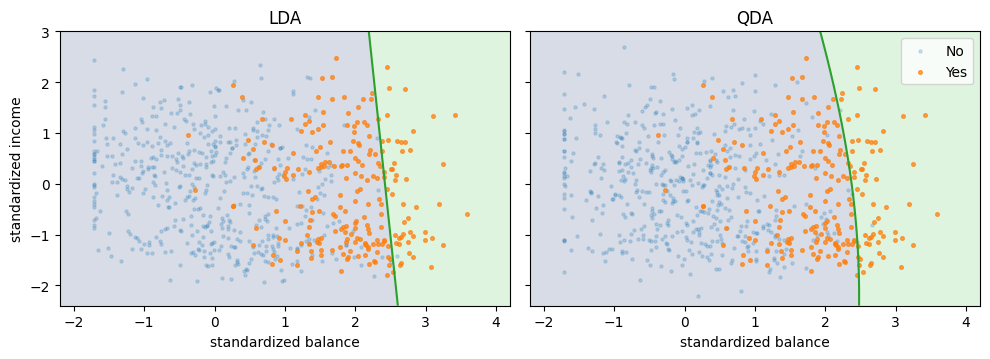

In [4]:
gx, gy = np.meshgrid(np.linspace(-2.2, 4.2, 240), np.linspace(-2.4, 3.0, 240))
grid = np.column_stack([gx.ravel(), gy.ravel()])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharex=True, sharey=True)
for ax, kind in zip(axes, ('lda', 'qda')):
    _, grid_prob = predict_gda(grid, params, kind)
    ax.contourf(gx, gy, grid_prob.reshape(gx.shape), levels=[0, .5, 1], alpha=.2)
    ax.contour(gx, gy, grid_prob.reshape(gx.shape), levels=[.5], colors='tab:green')
    neg = rng.choice(np.flatnonzero(y_train == 0), 500, replace=False)
    pos = np.flatnonzero(y_train == 1)
    ax.scatter(X_train[neg, 0], X_train[neg, 1], s=5, alpha=.2, label='No')
    ax.scatter(X_train[pos, 0], X_train[pos, 1], s=7, alpha=.7, label='Yes')
    ax.set(title=kind.upper(), xlabel='standardized balance')
axes[0].set_ylabel('standardized income')
axes[1].legend()
plt.tight_layout();

## Unequal decision costs

In [5]:
_, p_lda = predict_gda(X_test, params, 'lda')
for threshold in (0.50, 0.20, 0.05):
    pred = p_lda >= threshold
    tp = np.sum(pred & (y_test == 1))
    fp = np.sum(pred & (y_test == 0))
    fn = np.sum(~pred & (y_test == 1))
    print(f't={threshold:.2f}: TP={tp:3d}, FP={fp:4d}, FN={fn:3d}')

t=0.50: TP= 23, FP=   4, FN= 85
t=0.20: TP= 55, FP=  67, FN= 53
t=0.05: TP= 92, FP= 306, FN= 16


## Library comparison

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

for model in (LinearDiscriminantAnalysis(), QuadraticDiscriminantAnalysis()):
    model.fit(X_train, y_train)
    library_prob = model.predict_proba(X_test)[:, 1]
    _, scratch_prob = predict_gda(X_test, params, 'lda' if 'Linear' in type(model).__name__ else 'qda')
    print(type(model).__name__, 'maximum probability difference=',
          np.max(np.abs(library_prob - scratch_prob)))

LinearDiscriminantAnalysis maximum probability difference= 4.9960036108132044e-15
QuadraticDiscriminantAnalysis maximum probability difference= 5.995204332975845e-15


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [7]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '07-generative-classification'
NOTES = COURSE / 'lectures' / 'figures'

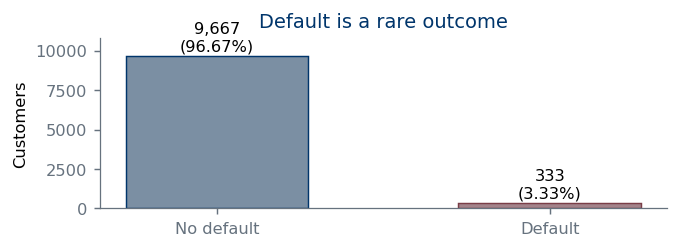

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/default-prevalence.pdf')

In [8]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde





SEED = 26507
rng = np.random.default_rng(SEED)

default = pd.read_csv('Default.csv')
y = (default["default"] == "Yes").to_numpy(int)
raw = default[["balance", "income"]].to_numpy(float)
mu_all, sd_all = raw.mean(axis=0), raw.std(axis=0)
x = (raw - mu_all) / sd_all


# Class prevalence is the first fact a classifier should confront.
fig, ax = plt.subplots(figsize=FULL_SHORT)
counts = np.bincount(y)
bars = ax.bar(["No default", "Default"], counts, color=[BLUE_FILL, RED_FILL],
              edgecolor=[BLUE, RED], linewidth=.8, width=0.55)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 120, f"{count:,}\n({count / len(y):.2%})", ha="center", va="bottom")
ax.set(ylabel="Customers", ylim=(0, 10800), title="Default is a rare outcome")
save(fig, OUT / "default-prevalence.pdf", OUT / "default-prevalence.svg")

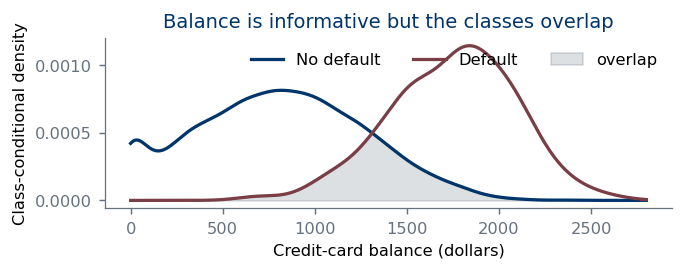

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/class-densities.pdf')

In [9]:
def fit_params(x_fit: np.ndarray, y_fit: np.ndarray):
    means = [x_fit[y_fit == k].mean(axis=0) for k in (0, 1)]
    covs = [np.cov(x_fit[y_fit == k].T) + 1e-3 * np.eye(2) for k in (0, 1)]
    pooled = sum((np.sum(y_fit == k) - 1) * covs[k] for k in (0, 1)) / (len(y_fit) - 2)
    priors = [np.mean(y_fit == k) for k in (0, 1)]
    return means, covs, pooled, priors


def log_gaussian(grid: np.ndarray, mean: np.ndarray, cov: np.ndarray) -> np.ndarray:
    delta = grid - mean
    inverse = np.linalg.inv(cov)
    return -0.5 * np.einsum("...i,ij,...j->...", delta, inverse, delta) - 0.5 * np.linalg.slogdet(cov)[1]


def plot_boundary(ax, x_fit, y_fit, kind, title, prior_one=None):
    means, covs, pooled, priors = fit_params(x_fit, y_fit)
    if prior_one is not None:
        priors = [1 - prior_one, prior_one]
    gx, gy = np.meshgrid(np.linspace(-2.3, 4.4, 240), np.linspace(-2.4, 3.1, 240))
    grid = np.dstack([gx, gy])
    use = [pooled, pooled] if kind == "LDA" else covs
    difference = (
        log_gaussian(grid, means[1], use[1])
        + np.log(priors[1])
        - log_gaussian(grid, means[0], use[0])
        - np.log(priors[0])
    )
    ax.contourf(gx, gy, difference, levels=[-1e9, 0, 1e9], colors=[BLUE_PALE, "#F8F1F2"], alpha=0.85)
    ax.contour(gx, gy, difference, levels=[0], colors=[GREEN], linewidths=1.8)
    neg = np.flatnonzero(y_fit == 0)
    pos = np.flatnonzero(y_fit == 1)
    if len(neg) > 650:
        neg = rng.choice(neg, 650, replace=False)
    if len(pos) > 350:
        pos = rng.choice(pos, 350, replace=False)
    ax.scatter(x_fit[neg, 0], x_fit[neg, 1], s=6, color=BLUE, alpha=0.28, linewidths=0)
    ax.scatter(x_fit[pos, 0], x_fit[pos, 1], s=8, color=RED, alpha=0.65, linewidths=0)
    ax.set(title=title, xlabel="Standardized balance", xlim=(-2.3, 4.4), ylim=(-2.4, 3.1))


# Real class-conditional balance densities and their overlap.
balance_no = default.loc[y == 0, "balance"].to_numpy(float)
balance_yes = default.loc[y == 1, "balance"].to_numpy(float)
grid_balance = np.linspace(0, 2800, 500)
density_no = gaussian_kde(balance_no)(grid_balance)
density_yes = gaussian_kde(balance_yes)(grid_balance)
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.plot(grid_balance, density_no, color=BLUE, label="No default")
ax.plot(grid_balance, density_yes, color=RED, label="Default")
ax.fill_between(grid_balance, np.minimum(density_no, density_yes), color=MUTED, alpha=0.22, label="overlap")
ax.set(xlabel="Credit-card balance (dollars)", ylabel="Class-conditional density", title="Balance is informative but the classes overlap")
ax.legend(ncol=3)
save(fig, OUT / "class-densities.pdf", OUT / "class-densities.svg")

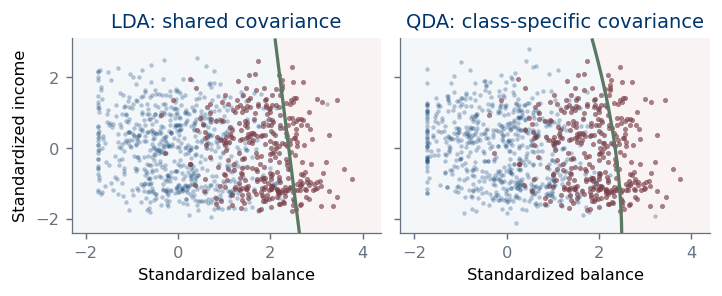

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/lda-qda-boundaries.pdf')

In [10]:
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharex=True, sharey=True)
plot_boundary(axes[0], x, y, "LDA", "LDA: shared covariance")
plot_boundary(axes[1], x, y, "QDA", "QDA: class-specific covariance")
axes[0].set_ylabel("Standardized income")
fig.tight_layout(w_pad=0.8)
save(fig, OUT / "lda-qda-boundaries.pdf", OUT / "lda-qda-boundaries.svg")

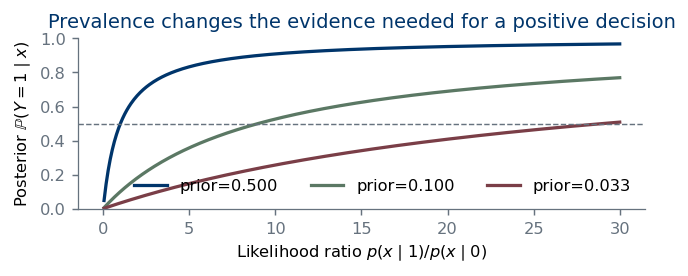

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/prior-shift.pdf')

In [11]:
# Prior shift with the likelihood ratio held fixed.
likelihood_ratio = np.linspace(0.05, 30, 500)
fig, ax = plt.subplots(figsize=FULL_SHORT)
for prior, color in [(0.50, BLUE), (0.10, GREEN), (y.mean(), RED)]:
    posterior = prior * likelihood_ratio / (prior * likelihood_ratio + 1 - prior)
    ax.plot(likelihood_ratio, posterior, color=color, label=f"prior={prior:.3f}")
ax.axhline(0.5, color=MUTED, linewidth=0.8, linestyle="--")
ax.set(xlabel="Likelihood ratio $p(x\mid1)/p(x\mid0)$", ylabel="Posterior $\mathbb{P}(Y=1\mid x)$", ylim=(0, 1), title="Prevalence changes the evidence needed for a positive decision")
ax.legend(ncol=3)
save(fig, OUT / "prior-shift.pdf", OUT / "prior-shift.svg")

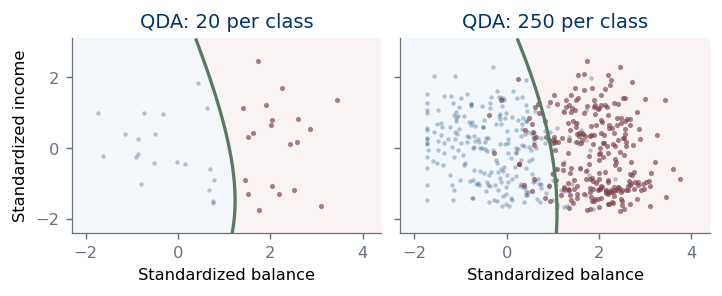

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/qda-sample-size.pdf')

In [12]:
# QDA on balanced real-data subsamples exposes covariance instability.
neg_all, pos_all = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, per_class in zip(axes, [20, 250]):
    idx = np.r_[rng.choice(neg_all, per_class, replace=False), rng.choice(pos_all, per_class, replace=False)]
    plot_boundary(ax, x[idx], y[idx], "QDA", f"QDA: {per_class} per class")
axes[0].set_ylabel("Standardized income")
fig.tight_layout(w_pad=0.8)
save(fig, OUT / "qda-sample-size.pdf", OUT / "qda-sample-size.svg")

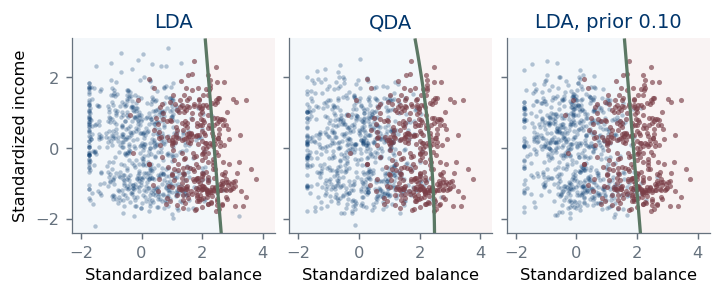

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/demo-generative-controls.pdf')

In [13]:
# Static fallback for the in-class control comparison.
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
plot_boundary(axes[0], x, y, "LDA", "LDA")
plot_boundary(axes[1], x, y, "QDA", "QDA")
plot_boundary(axes[2], x, y, "LDA", "LDA, prior 0.10", prior_one=0.10)
axes[0].set_ylabel("Standardized income")
fig.tight_layout(w_pad=0.5)
save(fig, OUT / "demo-generative-controls.pdf", OUT / "demo-generative-controls.svg")

In [14]:
print(f"Default rows: {len(default)}")
print(f"Default prevalence: {y.mean():.6f}")
print(f"Balance means, no/yes: {balance_no.mean():.2f}, {balance_yes.mean():.2f}")


def covariance_geometry():
    """Why the covariance assumption fixes the shape of the boundary.

    The real-data LDA/QDA figure cannot show this: on `Default` both fitted
    boundaries come out as near-identical vertical lines, so the linear-versus-
    quadratic distinction is invisible.  Two declared Gaussians per panel make
    the geometry explicit, which is the claim the algebra establishes.
    """
    mu0, mu1 = np.array([-1.3, 0.7]), np.array([1.3, -0.6])
    shared = np.array([[1.0, 0.62], [0.62, 0.85]])
    other = np.array([[3.0, 0.45], [0.45, 3.0]])
    panels = [
        ("LDA: shared $\\Sigma$", shared, shared, "boundary is a line"),
        ("QDA: separate $\\Sigma_k$", shared, other, "boundary is a conic"),
        ("Naive Bayes: diagonal $\\Sigma_k$", np.diag(np.diag(shared)),
         np.diag(np.diag(other)), "contours are axis aligned"),
    ]
    gx, gy = np.meshgrid(np.linspace(-7.0, 3.4, 420), np.linspace(-4.2, 4.2, 420))
    pts = np.dstack([gx, gy])

    def log_density(mean, cov):
        diff = pts - mean
        inv = np.linalg.inv(cov)
        quad = np.einsum("...i,ij,...j->...", diff, inv, diff)
        return -0.5*quad - 0.5*np.log(np.linalg.det(cov))

    fig, axes = plt.subplots(1, 3, figsize=(FULL[0], 1.95), sharex=True, sharey=True)
    for ax, (title, cov0, cov1, note) in zip(axes, panels):
        l0, l1 = log_density(mu0, cov0), log_density(mu1, cov1)
        # Equal priors, so the boundary is exactly where the log densities agree.
        ax.contour(gx, gy, l0, levels=np.log([.05, .2, .5]) + l0.max(),
                   colors=BLUE, linewidths=.8)
        ax.contour(gx, gy, l1, levels=np.log([.05, .2, .5]) + l1.max(),
                   colors=RED, linewidths=.8)
        ax.contour(gx, gy, l0 - l1, levels=[0], colors=GREEN, linewidths=1.6)
        ax.scatter(*mu0, color=BLUE, s=16, zorder=5)
        ax.scatter(*mu1, color=RED, s=16, zorder=5)
        ax.set(title=title, xlabel=note, xticks=[], yticks=[])
    fig.tight_layout(pad=0.3, w_pad=0.4)
    return save(fig, OUT / "covariance-geometry.pdf", OUT / "covariance-geometry.svg")

Default rows: 10000
Default prevalence: 0.033300
Balance means, no/yes: 803.94, 1747.82


In [15]:
def parameter_counts():
    """How many numbers each class-conditional model must estimate."""
    dims = np.arange(1, 31)
    counts = {
        "QDA: $K(d + d(d{+}1)/2)$": 2*(dims + dims*(dims+1)//2),
        "LDA: $Kd + d(d{+}1)/2$": 2*dims + dims*(dims+1)//2,
        "naive Bayes: $2Kd$": 2*2*dims,
        "logistic regression: $d+1$": dims + 1,
    }
    fig, ax = plt.subplots(figsize=(FULL[0], 1.9))
    for label, c in counts.items():
        ax.plot(dims, c, linewidth=1.3, label=label)
    ax.set_yscale("log")
    ax.set(xlabel="number of features $d$", ylabel="free parameters",
           title="cost of the covariance assumption, $K=2$ classes")
    ax.legend(fontsize=6.2, framealpha=0, loc="upper left")
    fig.tight_layout(pad=0.3)
    print("parameters at d=30:", {k: int(v[-1]) for k, v in counts.items()})
    return save(fig, OUT / "parameter-counts.pdf", OUT / "parameter-counts.svg")

In [16]:
def covariance_geometry_panels():
    """One figure per model family, for the slide that introduces each.

    Same declared Gaussians as covariance_geometry(), so the three panels line
    up with the combined comparison figure.
    """
    mu0, mu1 = np.array([-1.3, 0.7]), np.array([1.3, -0.6])
    shared = np.array([[1.0, 0.62], [0.62, 0.85]])
    other = np.array([[3.0, 0.45], [0.45, 3.0]])
    specs = [
        ("lda", shared, shared,
         "shared $\\Sigma$: the quadratic terms cancel, leaving a line"),
        ("qda", shared, other,
         "separate $\\Sigma_k$: the quadratic terms survive, leaving a conic"),
        ("nb", np.diag(np.diag(shared)), np.diag(np.diag(other)),
         "diagonal $\\Sigma_k$: contours align with the axes"),
    ]
    gx, gy = np.meshgrid(np.linspace(-7.0, 3.4, 420), np.linspace(-4.2, 4.2, 420))
    pts = np.dstack([gx, gy])

    def log_density(mean, cov):
        diff = pts - mean
        quad = np.einsum("...i,ij,...j->...", diff, np.linalg.inv(cov), diff)
        return -0.5*quad - 0.5*np.log(np.linalg.det(cov))

    out = []
    for name, cov0, cov1, subtitle in specs:
        fig, ax = plt.subplots(figsize=(FULL[0]*0.56, 1.72))
        l0, l1 = log_density(mu0, cov0), log_density(mu1, cov1)
        ax.contour(gx, gy, l0, levels=np.log([.05, .2, .5]) + l0.max(),
                   colors=BLUE, linewidths=.8)
        ax.contour(gx, gy, l1, levels=np.log([.05, .2, .5]) + l1.max(),
                   colors=RED, linewidths=.8)
        ax.contour(gx, gy, l0 - l1, levels=[0], colors=GREEN, linewidths=1.7)
        ax.scatter(*mu0, color=BLUE, s=16, zorder=5)
        ax.scatter(*mu1, color=RED, s=16, zorder=5)
        ax.set(xlabel=subtitle, xticks=[], yticks=[])
        fig.tight_layout(pad=0.3)
        out.append(save(fig, OUT / f"geometry-{name}.pdf", OUT / f"geometry-{name}.svg"))
    return out

In [17]:
def qda_variance():
    """QDA's boundary moves with the sample, because the rare class is small.

    Subsamples keep the natural 3.3% prevalence rather than being balanced: a
    balanced subsample fits a prior of 0.5 and puts the boundary somewhere the
    real-data fit never would, which makes it incomparable with the previous
    slide.  Drawing n rows at random instead means a small n simply gives few
    defaulters -- about 17 at n=500 -- which is exactly the cause of the
    instability being shown.
    """
    gen = np.random.default_rng(SEED)
    gx, gy = np.meshgrid(np.linspace(-2.4, 4.3, 220), np.linspace(-2.4, 3.0, 220))
    grid = np.dstack([gx, gy])

    fig, axes = plt.subplots(1, 2, figsize=(FULL[0], 1.95), sharex=True, sharey=True)
    for ax, n_sub in zip(axes, [500, 5000]):
        ax.scatter(x[y == 0, 0], x[y == 0, 1], s=3, color=BLUE_FILL, alpha=.07,
                   edgecolors="none", rasterized=True)
        ax.scatter(x[y == 1, 0], x[y == 1, 1], s=5, color=RED, alpha=.45,
                   edgecolors="none", rasterized=True, label="default")
        counts = []
        for _ in range(8):
            take = gen.choice(len(x), n_sub, replace=False)
            xs, ys = x[take], y[take]
            if (ys == 1).sum() < 5:
                continue
            counts.append(int((ys == 1).sum()))
            score = np.zeros(gx.shape)
            for k, sign in [(1, +1), (0, -1)]:
                rows = xs[ys == k]
                score += sign*(log_gaussian(grid, rows.mean(0), np.cov(rows.T))
                               + np.log((ys == k).mean()))
            ax.contour(gx, gy, score, levels=[0], colors=GREEN, linewidths=.9,
                       alpha=.8)
        ax.set(title=f"$n={n_sub:,}$: about {int(np.mean(counts))} defaulters",
               xlabel="standardized balance")
    axes[0].set_ylabel("standardized income")
    axes[0].legend(fontsize=6.4, framealpha=0, loc="upper right", markerscale=2)
    fig.tight_layout(pad=0.3, w_pad=0.5)
    return save(fig, OUT / "qda-variance.pdf", OUT / "qda-variance.svg")

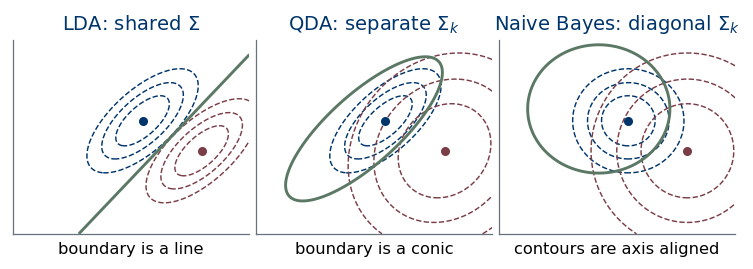

parameters at d=30: {'QDA: $K(d + d(d{+}1)/2)$': 990, 'LDA: $Kd + d(d{+}1)/2$': 525, 'naive Bayes: $2Kd$': 120, 'logistic regression: $d+1$': 31}


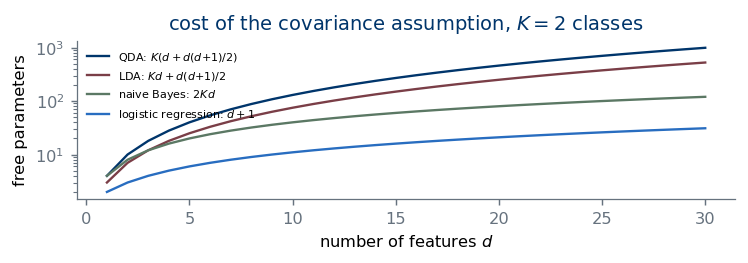

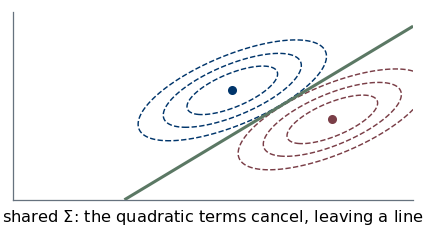

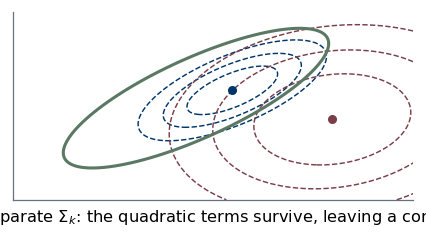

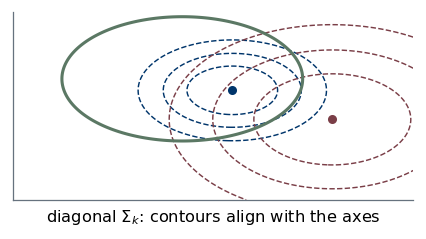

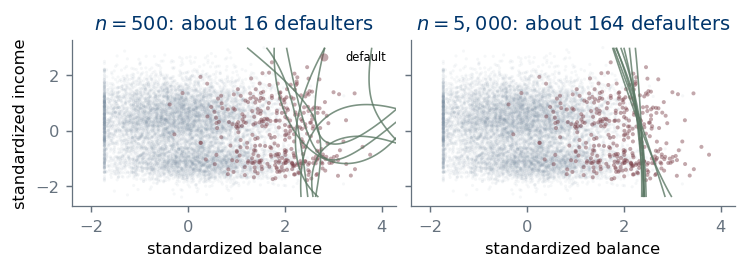

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/07-generative-classification/qda-variance.pdf')

In [18]:
# The four figures below are produced by the functions defined above; calling
# them here keeps `python make_generative_figures.py` a complete rebuild.
covariance_geometry()
parameter_counts()
covariance_geometry_panels()
qda_variance()